In [16]:
import polars as pl
import matplotlib.pyplot as plt

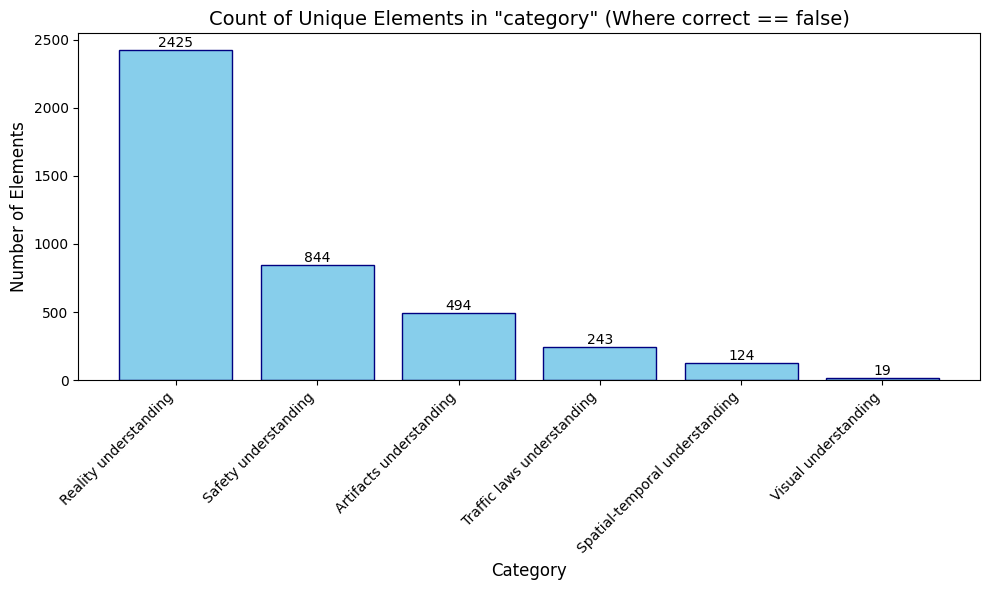

In [18]:
df_agent = pl.read_parquet("../dataset/dataset_final/results_analyzed_agent/Qwen3VL_Agent_analyzed.parquet")
# 1. Prepare the data
# We filter, grab the category column, and count unique occurrences
category_counts = (
    df_agent.filter(pl.col("correct") == "false")["category"]
    .value_counts(sort=True) # Sorts by count descending
)

# 2. Extract values for plotting
categories = category_counts["category"].to_list()
counts = category_counts["count"].to_list()

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color='skyblue', edgecolor='navy')

# Add styling and labels
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Elements', fontsize=12)
plt.title('Count of Unique Elements in "category" (Where correct == false)', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate labels if they are long

# Optional: Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()